# **E-commerce Sales & Customer Insights (EDA)**

### **Sourced Data Matrices & Initial EDA**

**1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**2. Load Dataset**

In [ ]:
# Load the dataset
restaurant_df = sns.load_dataset("tips")

# Display first 5 rows to understand structure
print("=== Dataset Sample Preview ===")
display(restaurant_df.head(5))

# Scan the dataset for any missing (null) values
print("\n=== Missing Values Audit ===")
print(restaurant_df.isna().sum())

=== Dataset Sample Preview ===


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



=== Missing Values Audit ===
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


**3: Data Cleaning aur Outliers**

Interquartile Range (IQR): 10.78
Mid-50% Range: 13.35 to 24.13


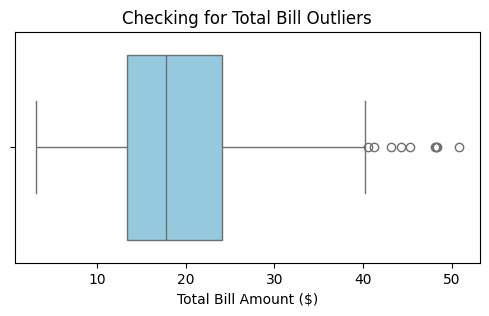

In [ ]:
# Calculate percentiles for outlier threshold
first_quartile = restaurant_df["total_bill"].quantile(0.25)
third_quartile = restaurant_df["total_bill"].quantile(0.75)
iqr_value = third_quartile - first_quartile

print(f"Interquartile Range (IQR): {iqr_value:.2f}")
print(f"Mid-50% Range: {first_quartile:.2f} to {third_quartile:.2f}")

# Plot a boxplot to spot statistical outliers
plt.figure(figsize=(6, 3))
sns.boxplot(data=restaurant_df, x="total_bill", color="skyblue")
plt.title("Checking for Total Bill Outliers")
plt.xlabel("Total Bill Amount ($)")
plt.show()

**4: Data Preprocessing (Encoding & Engineering)**

In [ ]:
# Convert categorical text data into binary flags
restaurant_df["sex_code"] = restaurant_df["sex"].replace(
    {"Female": 0, "Male": 1}
)
restaurant_df["smoker_code"] = restaurant_df["smoker"].replace(
    {"No": 0, "Yes": 1}
)

# Feature Engineering: Compute tip percentage relative to the bill
restaurant_df["tip_percentage"] = (
    restaurant_df["tip"] / restaurant_df["total_bill"]
) * 100

# Print clean text summary of first 5 rows
print("=== Feature Engineering Results ===")
print(
    restaurant_df[
        ["total_bill", "tip", "sex_code", "tip_percentage"]
    ].head()
)

=== Feature Engineering Results ===
   total_bill   tip sex_code  tip_percentage
0       16.99  1.01        0        5.944673
1       10.34  1.66        1       16.054159
2       21.01  3.50        1       16.658734
3       23.68  3.31        1       13.978041
4       24.59  3.61        0       14.680765


/tmp/ipykernel_2418/2932028405.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  restaurant_df["sex_code"] = restaurant_df["sex"].replace(
/tmp/ipykernel_2418/2932028405.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  restaurant_df["sex_code"] = restaurant_df["sex"].replace(
/tmp/ipykernel_2418/2932028405.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_opti

**Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

# Features and Target selection
X = df[["total_bill", "sex_code", "smoker_code", "size"]]
y = df["tip"]

# 80% Train and 20% Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Splitting Done! Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Splitting Done! Train rows: 195, Test rows: 49


**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Data  scale (standardize)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Applied Successfully!")

Feature Scaling Applied Successfully!


**5: Exploratory Data Visualization**

**Total Bill Distribution Plot**

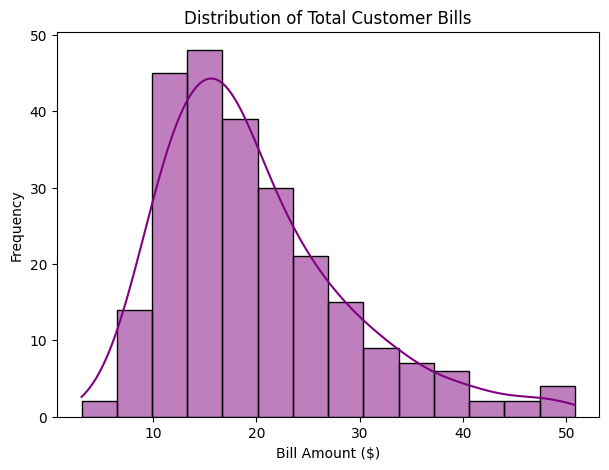

In [ ]:
# Set up the plotting area
plt.figure(figsize=(7, 5))

# Plot 1: Frequency distribution of total bill
sns.histplot(data=restaurant_df, x="total_bill", kde=True, color="purple")
plt.title("Distribution of Total Customer Bills")
plt.xlabel("Bill Amount ($)")
plt.ylabel("Frequency")

plt.show()

**Bill vs Tip Correlation Scatter**

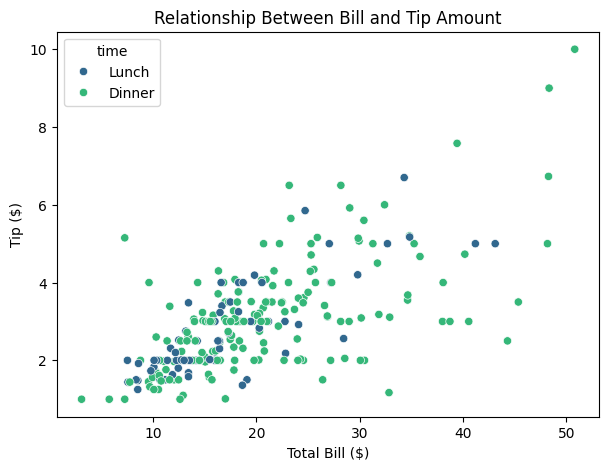

In [ ]:
# Set up the plotting area
plt.figure(figsize=(7, 5))

# Plot 2: Scatter plot analyzing bill
sns.scatterplot(
    x="total_bill", y="tip", hue="time", palette="viridis", data=restaurant_df
)
plt.title("Relationship Between Bill and Tip Amount")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")

plt.show()

**Feature Correlation Heatmap**

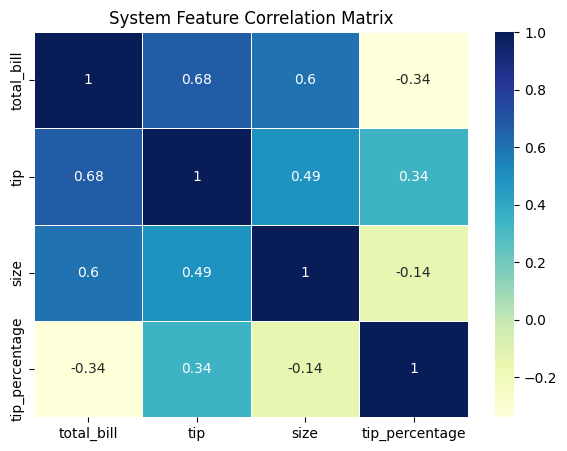

In [ ]:
# Set up the plotting area for heatmap
plt.figure(figsize=(7, 5))

# Plot 3: Heatmap to check features correlation matrix
sns.heatmap(
    restaurant_df.corr(numeric_only=True),
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
)
plt.title("System Feature Correlation Matrix")

plt.show()

**6: Summary and Business Insights**

In [ ]:
print(f"{' PROJECT SUMMARY ':=^40}")
print(f"Total Volume : {len(restaurant_df)} records")
print(f"Average Tip  : ${restaurant_df['tip'].mean():.2f}")
print(f"Max Bill     : ${restaurant_df['total_bill'].max():.2f}")
print(f"Peak Time    : {restaurant_df['time'].mode()[0]}")
print("=" * 40)

=========== PROJECT SUMMARY ============
Total Volume : 244 records
Average Tip  : $3.00
Max Bill     : $50.81
Peak Time    : Dinner
